**Note:** This file exists purely for benchmarking and validating that nano-Geneformer reproduces the behavior of the original Geneformer implementation. If you're looking for installation instructions or a quick start guide, please head over to README.

In [1]:
import os, sys, time
from pathlib import Path

ROOT = Path(".")
SCBERT_DIR = ROOT / "Geneformer"
NANO_DIR = ROOT / "nano-Geneformer"
DATA_PATH = ROOT / "pancreas.h5ad"

sys.path.insert(0, str(SCBERT_DIR))
sys.path.insert(0, str(NANO_DIR))

print(DATA_PATH.exists())
print(SCBERT_DIR.exists())
print(NANO_DIR.exists())

True
True
True


# Download example scRNA data

In [9]:
import gdown

url = 'https://drive.google.com/uc?id=1ehxgfHTsMZXy6YzlFKGJOsBKQ5rrvMnd'
output = 'pancreas.h5ad'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1ehxgfHTsMZXy6YzlFKGJOsBKQ5rrvMnd
From (redirected): https://drive.google.com/uc?id=1ehxgfHTsMZXy6YzlFKGJOsBKQ5rrvMnd&confirm=t&uuid=ec79e3d0-21ba-44ce-9e3f-7bdf0eadf591
To: /aiau001_scratch/hqn0001/projects/rule11/pancreas.h5ad
100%|██████████████████████████████████████████| 126M/126M [00:01<00:00, 88.9MB/s]


'pancreas.h5ad'

# Geneformer-V1

## official Geneformer (Geneformer-V1)

In [11]:
!python ./Geneformer/benchmark_official_geneformer.py \
  --input ./pancreas_v1_tokenized.pt \
  --model_path ./Geneformer/Geneformer-V1-10M \
  --output ./geneformer_v1_official_embeddings.npy \
  --batch_size 256 \
  --mode tokenized

Loading tokenized input...
Loading official Geneformer: ./Geneformer/Geneformer-V1-10M
BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/transform

## nano-Geneformer (Geneformer-V1)

In [9]:
!python ./nano-Geneformer/benchmark_nano_geneformer.py \
  --input ./pancreas_v1_tokenized.pt \
  --output ./nano_geneformer_v1_embeddings.npy \
  --model Geneformer-V1 \
  --batch_size 256 \
  --mode tokenized \
  --no_compile

Loading tokenized input...
Loading nano-Geneformer: Geneformer-V1
device=cuda, use_amp=True, compile_model=False, compile_mode=reduce-overhead, mode=tokenized, batch_size=256, pool=mean_pool, layer=-2
Warmup...
Average data loading time per batch: 0.0027 seconds
Average model inference time per batch: 0.0557 seconds
Total time for 15681 cells: 3.65 sec, 0.233 ms/cell
Throughput: 4295.03 cells/s
Peak GPU memory: 15.398 GB
Saved (15681, 256) to ./nano_geneformer_v1_embeddings.npy


## Embedding Reproducibility

In [14]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist


# Load embeddings
emb_official = np.load("./geneformer_v1_official_embeddings.npy")
emb_nano = np.load("./nano_geneformer_v1_embeddings_model.npy")

assert emb_official.shape == emb_nano.shape

print("shape:", emb_official.shape)


# Absolute difference
abs_diff = np.abs(emb_official - emb_nano)

print("\nmax abs diff:", abs_diff.max())
print("mean abs diff:", abs_diff.mean())


# Norm sanity check
official_norm = np.linalg.norm(emb_official, axis=1)
nano_norm = np.linalg.norm(emb_nano, axis=1)

print("\nofficial norm")
print(official_norm.min(), official_norm.mean(), official_norm.max())

print("\nnano norm")
print(nano_norm.min(), nano_norm.mean(), nano_norm.max())


# Correct cosine similarity
# Benchmark embeddings are NOT L2-normalized before saving,
# so normalize them here before computing cosine similarity.
eps = 1e-12

emb_official_normed = emb_official / np.clip(
    official_norm[:, None],
    eps,
    None,
)

emb_nano_normed = emb_nano / np.clip(
    nano_norm[:, None],
    eps,
    None,
)

cos = np.einsum(
    "ij,ij->i",
    emb_official_normed,
    emb_nano_normed,
)

print("\ncosine similarity")
print("mean cosine:", cos.mean())
print("median cosine:", np.median(cos))
print("min cosine:", cos.min())
print("max cosine:", cos.max())


# PCA variance spectrum
pca_off = PCA()
pca_off.fit(emb_official)

pca_nano = PCA()
pca_nano.fit(emb_nano)

print("\nofficial first 10 PCs")
print(pca_off.explained_variance_ratio_[:10])

print("\nnano first 10 PCs")
print(pca_nano.explained_variance_ratio_[:10])


# Pairwise distance preservation
np.random.seed(0)

idx = np.random.choice(
    len(emb_nano),
    1000,
    replace=False,
)

d1 = pdist(emb_official[idx])
d2 = pdist(emb_nano[idx])

corr = np.corrcoef(d1, d2)[0, 1]

print("\ndistance correlation =", corr)

shape: (15681, 256)

max abs diff: 0.0012087785
mean abs diff: 2.8276143e-05

official norm
0.73438424 1.1156262 1.561728

nano norm
0.734379 1.1156267 1.5616834

cosine similarity
mean cosine: 0.9999999
median cosine: 0.9999999
min cosine: 0.99999076
max cosine: 1.0000002

official first 10 PCs
[0.25597727 0.13446088 0.12329372 0.03646599 0.03366756 0.02296549
 0.01815506 0.01637016 0.01279019 0.0116168 ]

nano first 10 PCs
[0.25598294 0.13446088 0.12329338 0.03646519 0.03366781 0.02296575
 0.01815505 0.01636996 0.01279081 0.01161658]

distance correlation = 0.9999990460546644


# Geneformer-V2-104M

## official Geneformer (Geneformer-V2-104M)

In [26]:
!python ./Geneformer/benchmark_official_geneformer.py \
  --input ./pancreas_v2_104M_tokenized.pt \
  --model_path ./Geneformer/Geneformer-V2-104M \
  --output ./geneformer_v2_104M_official_embeddings.npy \
  --batch_size 256 \
  --mode tokenized \
  --special_token

Loading tokenized input...
Loading official Geneformer: ./Geneformer/Geneformer-V2-104M
BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/transfor

## nano-Geneformer (Geneformer-V2-104M)

In [19]:
!python ./nano-Geneformer/benchmark_nano_geneformer.py \
  --input ./pancreas_v2_104M_tokenized.pt \
  --output ./nano_geneformer_v2_104M_embeddings.npy \
  --model Geneformer-V2-104M \
  --batch_size 256 \
  --mode tokenized \
  --no_compile

Loading tokenized input...
Loading nano-Geneformer: Geneformer-V2-104M
device=cuda, use_amp=True, compile_model=False, compile_mode=reduce-overhead, mode=tokenized, batch_size=256, pool=mean_pool, layer=-2
Warmup...
Average data loading time per batch: 0.0034 seconds
Average model inference time per batch: 0.3541 seconds
Total time for 15681 cells: 22.23 sec, 1.417 ms/cell
Throughput: 705.52 cells/s
Peak GPU memory: 14.691 GB
Saved (15681, 768) to ./nano_geneformer_v2_104M_embeddings.npy


## Embedding Reproducibility

In [27]:
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist


# paths
official_path = Path("./geneformer_v2_104M_official_embeddings.npy")
nano_path = Path("./nano_geneformer_v2_104M_embeddings.npy")

# load embeddings
emb_official = np.load(official_path)
emb_nano = np.load(nano_path)

assert emb_official.shape == emb_nano.shape

print("shape:", emb_official.shape)


# Absolute difference
abs_diff = np.abs(emb_official - emb_nano)

print("\nmax abs diff:", abs_diff.max())
print("mean abs diff:", abs_diff.mean())


# Norm sanity check
official_norm = np.linalg.norm(emb_official, axis=1)
nano_norm = np.linalg.norm(emb_nano, axis=1)

print("\nofficial norm")
print(official_norm.min(), official_norm.mean(), official_norm.max())

print("\nnano norm")
print(nano_norm.min(), nano_norm.mean(), nano_norm.max())


# Correct cosine similarity
eps = 1e-12

emb_official_normed = emb_official / np.clip(
    official_norm[:, None],
    eps,
    None,
)

emb_nano_normed = emb_nano / np.clip(
    nano_norm[:, None],
    eps,
    None,
)

cos = np.einsum("ij,ij->i", emb_official_normed, emb_nano_normed)

print("\ncosine similarity")
print("mean cosine:", cos.mean())
print("median cosine:", np.median(cos))
print("min cosine:", cos.min())
print("max cosine:", cos.max())


# PCA variance spectrum
pca_off = PCA()
pca_off.fit(emb_official)

pca_nano = PCA()
pca_nano.fit(emb_nano)

print("\nofficial first 10 PCs")
print(pca_off.explained_variance_ratio_[:10])

print("\nnano first 10 PCs")
print(pca_nano.explained_variance_ratio_[:10])


# Pairwise distance preservation
np.random.seed(0)

idx = np.random.choice(
    len(emb_nano),
    1000,
    replace=False,
)

d1 = pdist(emb_official[idx])
d2 = pdist(emb_nano[idx])

corr = np.corrcoef(d1, d2)[0, 1]

print("\ndistance correlation =", corr)

shape: (15681, 768)

max abs diff: 0.0013097301
mean abs diff: 6.279231e-05

official norm
6.833732 8.256008 9.924331

nano norm
6.8338823 8.25601 9.924575

cosine similarity
mean cosine: 1.0
median cosine: 1.0
min cosine: 0.99999934
max cosine: 1.0000005

official first 10 PCs
[0.26359156 0.22187515 0.08065796 0.05615975 0.03130715 0.02565328
 0.02077447 0.01882668 0.01408839 0.01221989]

nano first 10 PCs
[0.26359218 0.22187528 0.08065839 0.05615889 0.03130712 0.02565334
 0.02077473 0.01882661 0.01408797 0.01222031]

distance correlation = 0.9999999706355094


# Geneformer-V2-316M

## official Geneformer (Geneformer-V2-316M)

In [30]:
!python ./Geneformer/benchmark_official_geneformer.py \
  --input ./pancreas_v2_316M_tokenized.pt \
  --model_path ./Geneformer/Geneformer-V2-316M \
  --output ./geneformer_v2_316M_official_embeddings.npy \
  --batch_size 256 \
  --mode tokenized \
  --special_token

Loading tokenized input...
Loading official Geneformer: ./Geneformer/Geneformer-V2-316M
BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/transfor

## nano-Geneformer (Geneformer-V2-316M)

In [31]:
!python ./nano-Geneformer/benchmark_nano_geneformer.py \
  --input ./pancreas_v2_316M_tokenized.pt \
  --output ./nano_geneformer_v2_316M_embeddings.npy \
  --model Geneformer-V2-316M \
  --batch_size 256 \
  --mode tokenized \
  --no_compile

Loading tokenized input...
Loading nano-Geneformer: Geneformer-V2-316M
device=cuda, use_amp=True, compile_model=False, compile_mode=reduce-overhead, mode=tokenized, batch_size=256, pool=mean_pool, layer=-2
Warmup...
Average data loading time per batch: 0.0036 seconds
Average model inference time per batch: 0.9069 seconds
Total time for 15681 cells: 56.51 sec, 3.604 ms/cell
Throughput: 277.47 cells/s
Peak GPU memory: 17.094 GB
Saved (15681, 1152) to ./nano_geneformer_v2_316M_embeddings.npy


## Embedding Reproducibility

In [32]:
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist


# paths
official_path = Path("./geneformer_v2_316M_official_embeddings.npy")
nano_path = Path("./nano_geneformer_v2_316M_embeddings.npy")

# load embeddings
emb_official = np.load(official_path)
emb_nano = np.load(nano_path)

assert emb_official.shape == emb_nano.shape

print("shape:", emb_official.shape)


# Absolute difference
abs_diff = np.abs(emb_official - emb_nano)

print("\nmax abs diff:", abs_diff.max())
print("mean abs diff:", abs_diff.mean())


# Norm sanity check
official_norm = np.linalg.norm(emb_official, axis=1)
nano_norm = np.linalg.norm(emb_nano, axis=1)

print("\nofficial norm")
print(official_norm.min(), official_norm.mean(), official_norm.max())

print("\nnano norm")
print(nano_norm.min(), nano_norm.mean(), nano_norm.max())


# Correct cosine similarity
eps = 1e-12

emb_official_normed = emb_official / np.clip(
    official_norm[:, None],
    eps,
    None,
)

emb_nano_normed = emb_nano / np.clip(
    nano_norm[:, None],
    eps,
    None,
)

cos = np.einsum("ij,ij->i", emb_official_normed, emb_nano_normed)

print("\ncosine similarity")
print("mean cosine:", cos.mean())
print("median cosine:", np.median(cos))
print("min cosine:", cos.min())
print("max cosine:", cos.max())


# PCA variance spectrum
pca_off = PCA()
pca_off.fit(emb_official)

pca_nano = PCA()
pca_nano.fit(emb_nano)

print("\nofficial first 10 PCs")
print(pca_off.explained_variance_ratio_[:10])

print("\nnano first 10 PCs")
print(pca_nano.explained_variance_ratio_[:10])


# Pairwise distance preservation
np.random.seed(0)

idx = np.random.choice(
    len(emb_nano),
    1000,
    replace=False,
)

d1 = pdist(emb_official[idx])
d2 = pdist(emb_nano[idx])

corr = np.corrcoef(d1, d2)[0, 1]

print("\ndistance correlation =", corr)

shape: (15681, 1152)

max abs diff: 0.00074112415
mean abs diff: 5.2472737e-05

official norm
4.3315277 4.8978767 6.600861

nano norm
4.331552 4.897873 6.601419

cosine similarity
mean cosine: 1.0
median cosine: 0.9999999
min cosine: 0.9999995
max cosine: 1.0000002

official first 10 PCs
[0.24870181 0.19892032 0.07675329 0.03764156 0.03141154 0.02400531
 0.01972824 0.01624381 0.01152609 0.00956419]

nano first 10 PCs
[0.24870107 0.19892067 0.0767541  0.03764179 0.0314121  0.02400564
 0.01972809 0.01624385 0.01152605 0.00956429]

distance correlation = 0.9999998649577522


## Visualization

Using label key: cell_type
Embedding shape: (15681, 1152)
mean cosine: 1.0
median cosine: 0.9999999
min cosine: 0.9999996
max abs diff: 0.00018745661
mean abs diff: 1.0659388e-05


/aiau001_scratch/hqn0001/envs/hub/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


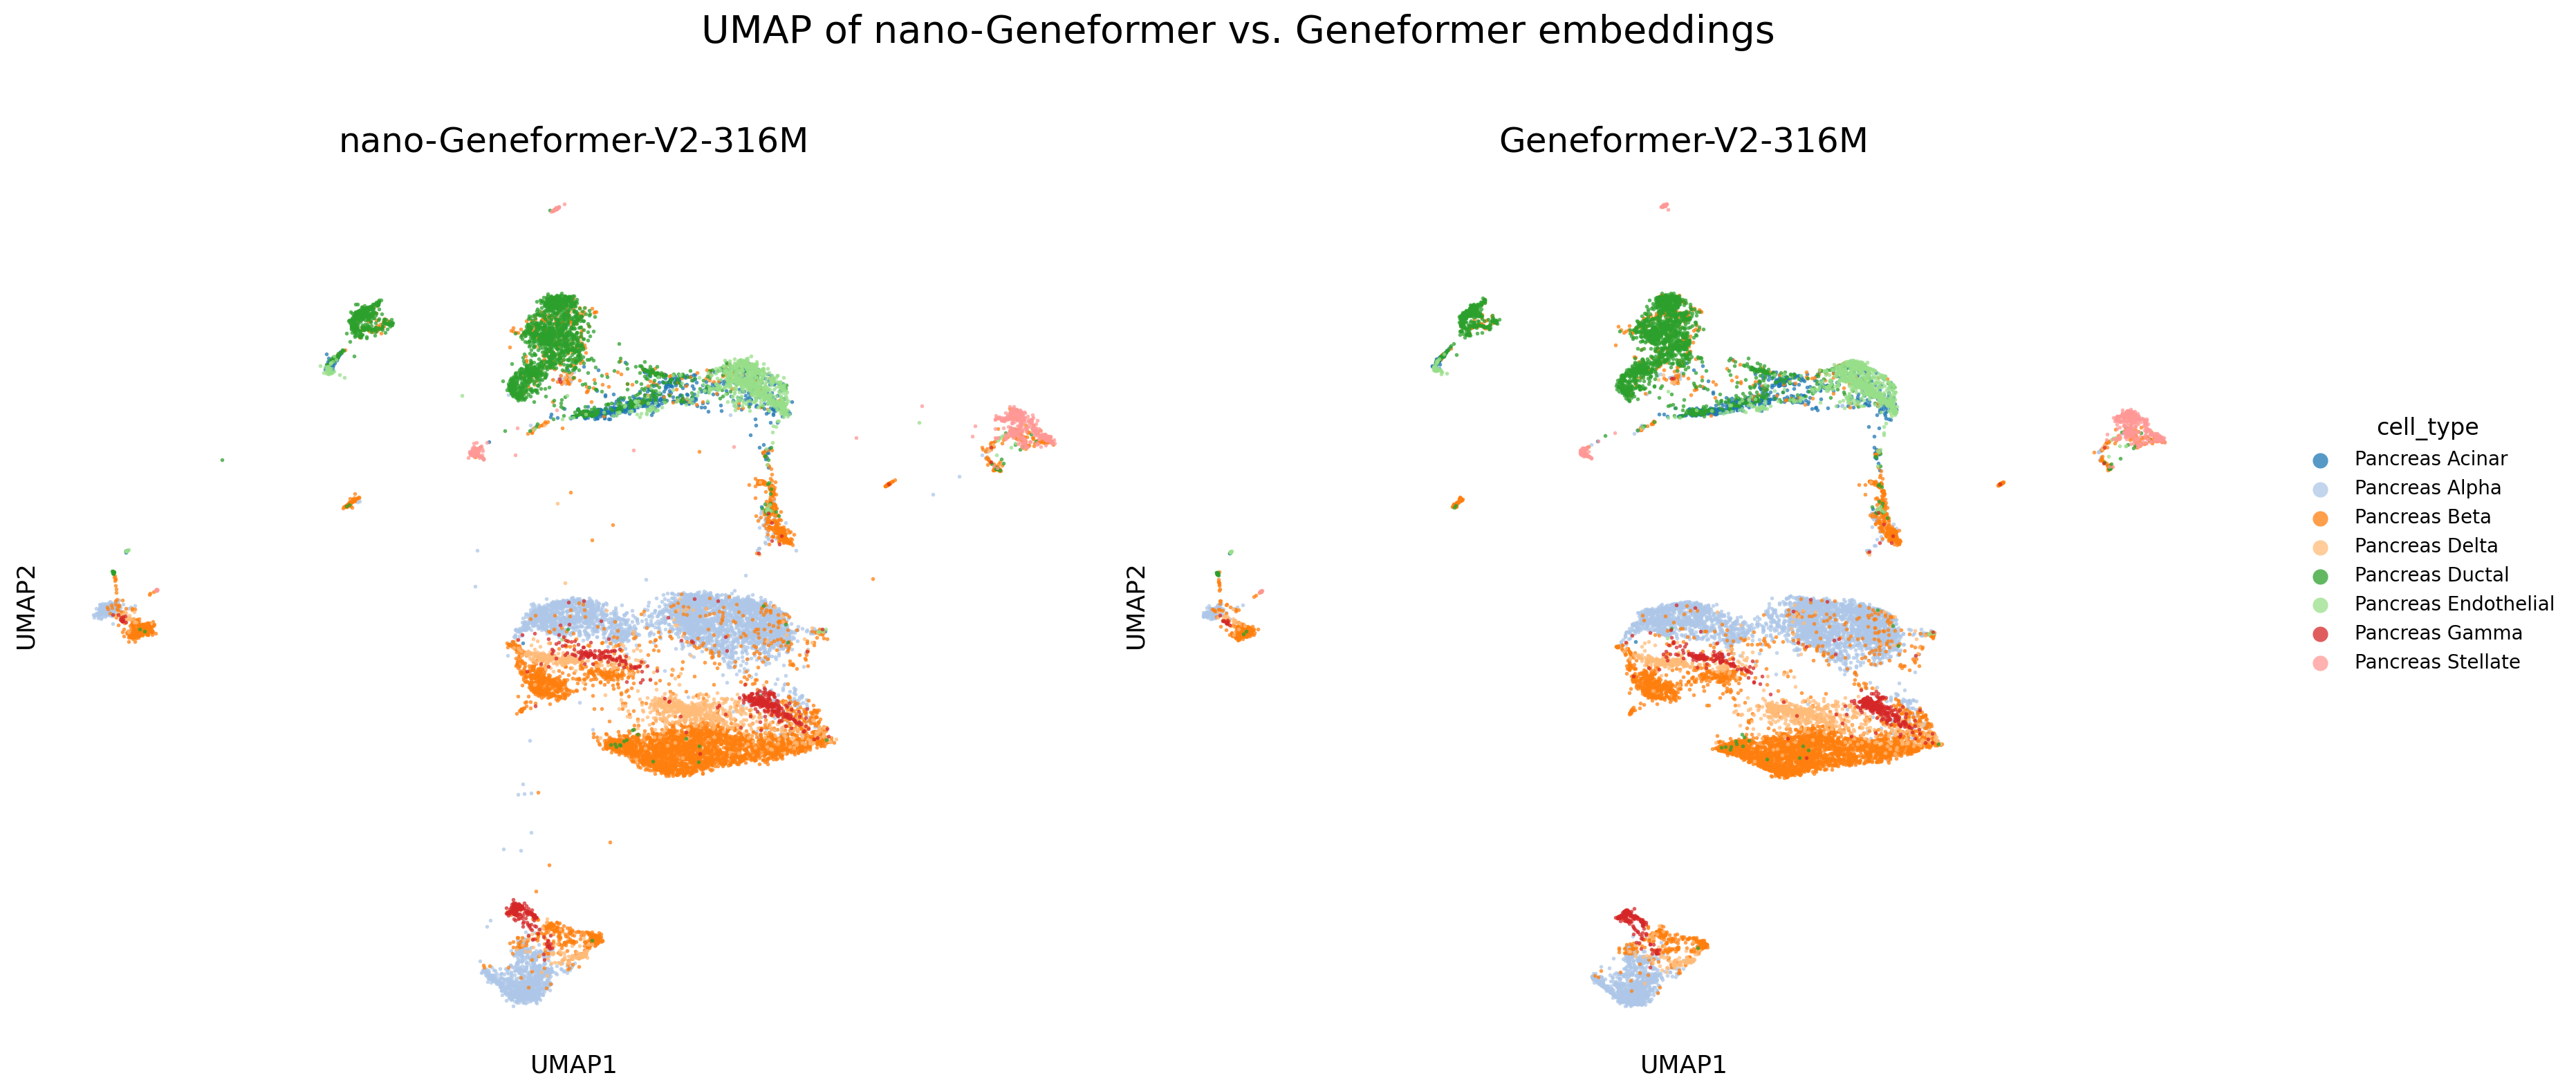

Saved: ./umap_nano_geneformer_vs_geneformer.png


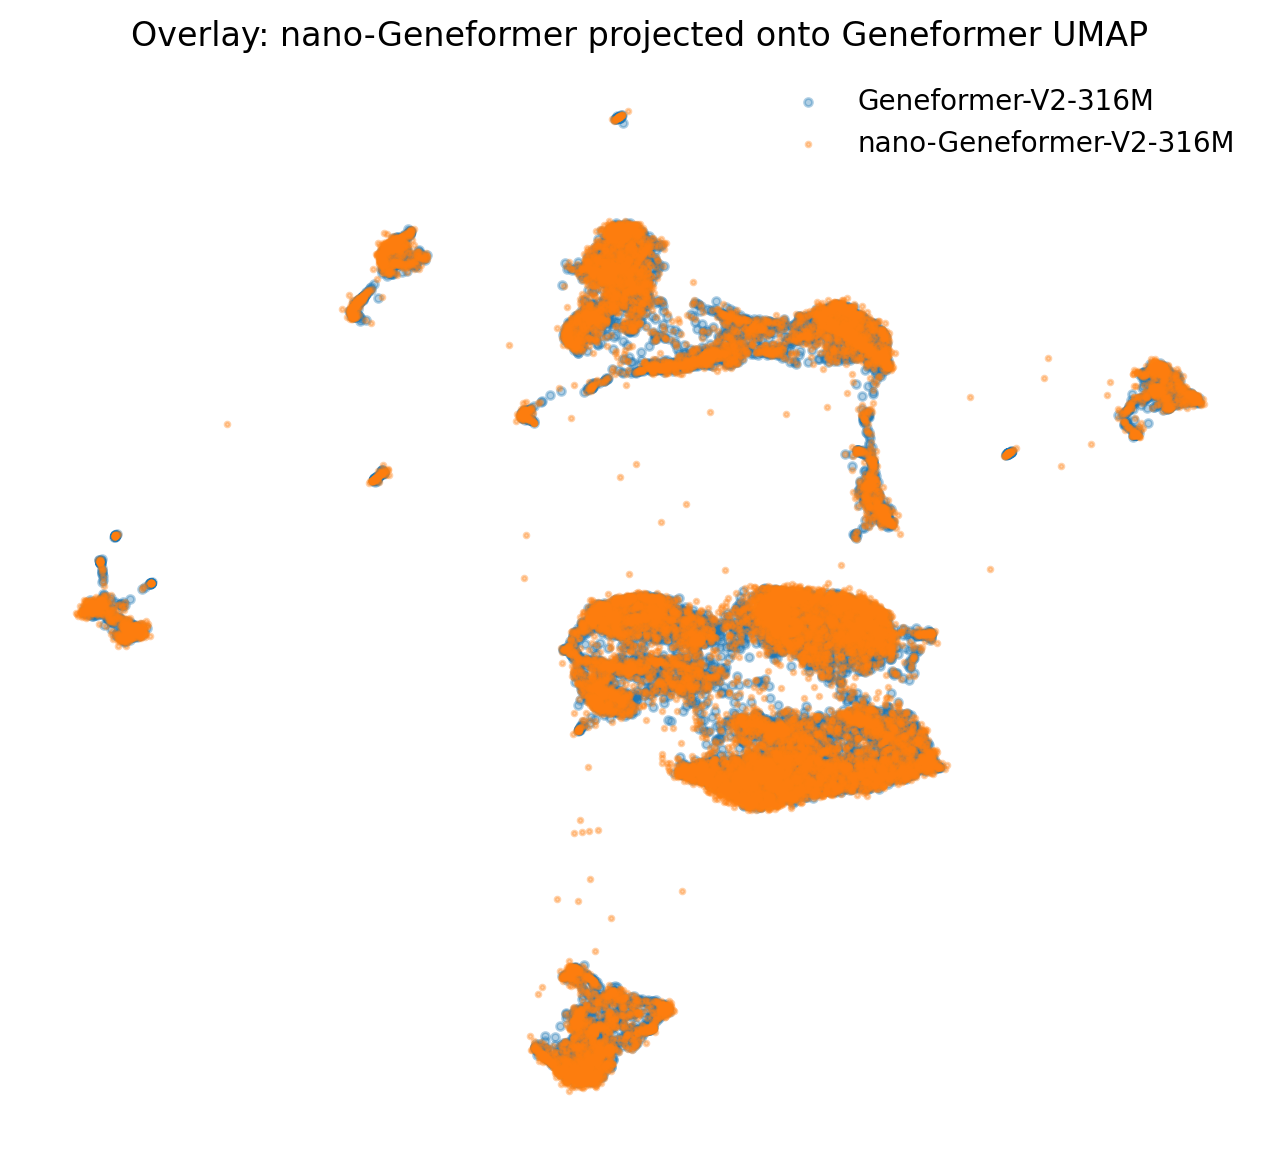

Saved: ./umap_overlay_nano_geneformer_vs_geneformer.png


In [36]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import umap
from pathlib import Path

# paths
official_path = Path("./geneformer_v2_316M_official_embeddings.npy")
nano_path = Path("./nano_geneformer_v2_316M_embeddings.npy")
adata_path = Path("./pancreas.h5ad")

# load
emb_official = np.load(official_path)
emb_nano = np.load(nano_path)
adata = sc.read_h5ad(adata_path)

assert emb_official.shape == emb_nano.shape
assert emb_official.shape[0] == adata.n_obs

# labels
possible_keys = ["celltype", "cell_type", "CellType"]

label_key = None
for k in possible_keys:
    if k in adata.obs.columns:
        label_key = k
        break

if label_key is None:
    raise ValueError(f"Cannot find cell type column. Available obs columns: {list(adata.obs.columns)}")

labels = adata.obs[label_key].astype(str).values
classes = np.unique(labels)

print("Using label key:", label_key)
print("Embedding shape:", emb_nano.shape)

# normalize
def l2norm(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)

emb_official_n = l2norm(emb_official)
emb_nano_n = l2norm(emb_nano)

#  metrics 
cos = np.sum(emb_official_n * emb_nano_n, axis=1)
abs_diff = np.abs(emb_official_n - emb_nano_n)

print("mean cosine:", cos.mean())
print("median cosine:", np.median(cos))
print("min cosine:", cos.min())
print("max abs diff:", abs_diff.max())
print("mean abs diff:", abs_diff.mean())

# UMAP 
# Fit UMAP on official scBERT, then project nano-scBERT into same UMAP space
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=0,
)

xy_official = reducer.fit_transform(emb_official_n)
xy_nano = reducer.transform(emb_nano_n)

# side-by-side plot 
fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=200)

cmap = plt.get_cmap("tab20")
color_map = {c: cmap(i % 20) for i, c in enumerate(classes)}

for ax, xy_i, title in [
    (axes[0], xy_nano, "nano-Geneformer-V2-316M"),
    (axes[1], xy_official, "Geneformer-V2-316M"),
]:
    for c in classes:
        idx = labels == c
        ax.scatter(
            xy_i[idx, 0],
            xy_i[idx, 1],
            s=4,
            alpha=0.75,
            color=color_map[c],
            label=c,
            linewidths=0,
        )

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("UMAP1", fontsize=13)
    ax.set_ylabel("UMAP2", fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

handles, legend_labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    title=label_key,
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
    frameon=False,
    markerscale=4,
    fontsize=10,
    title_fontsize=12,
)

fig.suptitle(
    "UMAP of nano-Geneformer vs. Geneformer embeddings",
    fontsize=20,
    y=0.98,
)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])

out_png = "./umap_nano_geneformer_vs_geneformer.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved:", out_png)

# ---------- overlay plot ----------
plt.figure(figsize=(8, 7), dpi=200)
plt.scatter(
    xy_official[:, 0],
    xy_official[:, 1],
    s=8,
    alpha=0.35,
    label="Geneformer-V2-316M",
)
plt.scatter(
    xy_nano[:, 0],
    xy_nano[:, 1],
    s=3,
    alpha=0.35,
    label="nano-Geneformer-V2-316M",
)
plt.legend(frameon=False)
plt.title("Overlay: nano-Geneformer projected onto Geneformer UMAP")
plt.xticks([])
plt.yticks([])
plt.axis("off")

out_overlay = "./umap_overlay_nano_geneformer_vs_geneformer.png"
plt.savefig(out_overlay, bbox_inches="tight")
plt.show()

print("Saved:", out_overlay)